In [1]:
XLA_PYTHON_CLIENT_MEM_FRACTION=.5


import jax.numpy as jnp

import scipy.io as sio
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.sparse.linalg import eigsh
#%matplotlib inline
#import utils



def getKsTerms(Xs1,Xs2,M=jnp.inf,F=jnp.inf):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    
    Phr=(P-1)/(M-1)
    Qhr=(Q-1)/(F-1)
    Pr=P/M
    Qr=Q/F
    
    #if False:
    if P<Q:
        Kv=1/Q*jnp.matmul(Xs1,Xs2.T)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))
        #nTrKs_min2=jnp.mean(jnp.square(1/Q*jnp.matmul(Xs1,Xs2.T)))
    else:
        Kv=1/P*jnp.matmul(Xs1.T,Xs2)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))
        #nTrKs_min2=jnp.mean(jnp.square(1/P*jnp.matmul(Xs1.T,Xs2)))
            
    Term2=-(1-Phr)/P * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=1)))
    Term3=-(1-Qhr)/Q * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=0)))
    Term4=((1-Phr)*(1-Qhr))/(P*Q) * jnp.mean(jnp.power(Xs1*Xs2,2))
        
    v =  Term2 + Term3 + Term4
    
    nsTrKs = jnp.square(jnp.mean(Xs1*Xs2))
    
    # if M and F are infinite, or even if M and F are finite:
    denom =  (nTrKs_min2 +v)
    numer =  (nsTrKs +v)
    # There are some scaling differences, but all that matters is numer/denom, which cancels out the scaling factors.
    
    gammas=nsTrKs/nTrKs_min2
    gamma_mp1=gammas*P/(P-gammas)
    gamma_mp2=gammas*Q/(Q-gammas)
    
    return numer , denom , gammas, gamma_mp1,gamma_mp2

def getKong(Xs1,Xs2):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    
    Kc = jnp.matmul(Xs1,Xs2.T)/Q

    #Knan = jnp.where(jnp.eye(P),jnp.nan,Kc)
    #KongEst = jnp.nanmean(jnp.square(Knan))
    KongEst = 2*jnp.trace(jnp.matmul(np.triu(Kc, 1),Kc))/(P*(P-1))
    return KongEst

def getKsTerms2(Xs1,Xs2):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    
    denom=getKong(Xs1,Xs2)*(P-1)/P
    
    numer=jnp.square(jnp.mean(Xs1*Xs2))
    
    return numer, denom
    
def getBias(x,y):
    #x/y
    #y_mean=np.mean(y)
    #y_var=np.square(np.std(y))

    x_mean=np.mean(x)
    y_mean=np.mean(y)
    y_var=np.square(np.std(y))/(np.shape(x)[0])

    xy_cov=np.mean((x-x_mean)*(y-y_mean))/(np.shape(x)[0])
    #xy_cov=np.cov(x,y)[0][1]
    
    bias = (x_mean/(y_mean**3))*y_var-1/np.square(y_mean)*xy_cov
    #bias_sample_corrected = bias/(np.shape(x)[0])
    
    return bias

def plotER(ax,xoi,qoi,cv='k',lv=''):
    yval=np.mean(qoi,axis=1)
    lower_error=np.quantile(qoi,axis=1,q=0.25)
    upper_error=np.quantile(qoi,axis=1,q=0.75)
    asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
    ax.errorbar(xoi, yval, yerr=asymmetric_error,c=cv,marker='o',ls='-',ms=3,label=lv)#, fmt='o')


def re(x):
    xv=np.array(x)
    return np.where(xv>0,xv,0)


def cal_gauss_est(Phi1,Phi2):
    NT=jnp.shape(Phi1)[0]
    N=jnp.shape(Phi1)[1]
    #NT=10000
    #N=10000
    c_hat = 1/NT*jnp.matmul(Phi1.T,Phi2) #normalized and shifted:
    #c_hat=jnp.cov(Phi.T)
    
    #N = c_hat.shape[0]  # Assuming c_hat is a square matrix
    #NT = N  # Adjust this if NT differs from N

    # Calculate \overline{a}
    a_bar = jnp.trace(c_hat) / N

    # Calculate \overline{c}
    sum_c = jnp.sum(c_hat) - jnp.trace(c_hat)
    c_bar = sum_c / (N * (N - 1))

    # Calculate \delta\hat{a}^2
    delta_a_squared = jnp.sum((jnp.diagonal(c_hat) - a_bar) ** 2) / (N - 1)

    # Calculate \delta\hat{c}^2
    #c_no_diag = c_hat.copy()
    #np.fill_diagonal(c_no_diag, 0)
    c_hat_cen=c_hat-c_bar
    #jnp.fill_diagonal(c_hat_cen, 0)
    c_hat_cen=jnp.where(1==jnp.eye(jnp.shape(c_hat)[0]),0,c_hat_cen)

    delta_c_squared = jnp.sum(c_hat_cen ** 2) / (N * (N - 1) - 2)

    # Calculate C2
    C2 = ((NT - 1) / NT) * delta_c_squared - ((a_bar ** 2 - c_bar ** 2) / NT) - \
         (4 / (N + 1)) * ((c_bar ** 2 - a_bar * c_bar) / NT)

    # Calculate A2
    A2 = ((NT - 1) / (NT + 1)) * delta_a_squared - \
         2 * ((a_bar ** 2 - c_bar ** 2) / (NT + 1)) + \
         (2 * delta_c_squared / (NT + 1))

    numer = N*a_bar**2
    denom = (a_bar**2 + A2) + (N-1) * (c_bar**2 + C2)
    #return a_bar, c_bar, delta_a_squared, delta_c_squared, C2, A2
    return numer, denom




In [2]:
XLA_PYTHON_CLIENT_MEM_FRACTION=.9


import jax.numpy as jnp

import scipy.io as sio
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.sparse.linalg import eigsh
#%matplotlib inline
#import utils
import jax

import math
import os
from functools import partial
from jax import random


def gett_all(ijlm, A,B):
    i, j, l, m = list(ijlm)
    pexp = i+'a,'+j+'a,'+l+'b,'+m+'b->'
    qexp = i+'a,'+j+'a,'+l+'a,'+m+'a->'
    pval = jnp.einsum(pexp, A, B, A, B)
    pqval = pval - jnp.einsum(qexp, A, B, A, B)
    return pval,pqval

@partial(jax.jit, static_argnames=['P','Q'])
def getest_all0(Xs1,Xs2,P,Q,M=jnp.inf,F=jnp.inf):
    #P=jnp.shape(Xs1)[0]
    #Q=jnp.shape(Xs1)[1]
    #Xs1=Xs1_o-jnp.sum(Xs1_o,axis=0)/P
    #Xs2=Xs2_o-jnp.sum(Xs2_o,axis=0)/P

    Phr=(P-1)/(M-1)
    Qhr=(Q-1)/(F-1)
    
    if P<Q:
        Kv=1/Q*jnp.matmul(Xs1,Xs2.T)
        nTrKs_min2=jnp.sum(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))/P
        #nTrKs_min2=jnp.mean(jnp.square(1/Q*jnp.matmul(Xs1,Xs2.T)))
    else:
        Kv=1/P*jnp.matmul(Xs1.T,Xs2)
        nTrKs_min2=jnp.sum(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))/Q
        #nTrKs_min2=jnp.mean(jnp.square(1/P*jnp.matmul(Xs1.T,Xs2)))
            
    Term2=-(1-Phr)/P * jnp.sum(jnp.square(jnp.sum(Xs1*Xs2,axis=1)/Q ))/P
    Term3=-(1-Qhr)/Q * jnp.sum(jnp.square(jnp.sum(Xs1*Xs2,axis=0)/P ))/Q
    Term4=((1-Phr)*(1-Qhr))/(P*Q) * jnp.sum(jnp.power(Xs1*Xs2,2))/(P*Q)
        
    v =  Term2 + Term3 + Term4
    
    nsTrKs = jnp.square(jnp.sum(Xs1*Xs2)/(P*Q))
    
    # if M and F are infinite, or even if M and F are finite:
    numer =  (nsTrKs +v)
    denom =  (nTrKs_min2 +v)

    naive=[nsTrKs, nTrKs_min2]
    row_exp=[nsTrKs+Term2,  nTrKs_min2+Term2]
    col_exp=[nsTrKs+Term3,  nTrKs_min2+Term3]
    double_exp=[numer, denom]
        
    return naive, row_exp, col_exp, double_exp
    
@partial(jax.jit, static_argnames=['P','Q'])
def getest_all(A,B,P,Q):
    nf = jnp.sqrt(P)*jnp.sqrt(Q)
    # Wrap *all* the following in a single shared_intermediates context
    #with shared_intermediates():
    t1,t1d = gett_all('ijji', A/nf, B/nf)
    t2,t2d = gett_all('iiii', A/nf, B/nf)
    t3,t3d = gett_all('ijjj', A/nf, B/nf)
    #t4,t4d = gett_all('iiij', A/nf)#<
    t5,t5d = gett_all('ijjl', A/nf, B/nf)
    t6,t6d = gett_all('iijj', A/nf, B/nf)
    t7,t7d = gett_all('iijl', A/nf, B/nf)
    #t8,t8d = gett_all('ijll', A/nf)#<
    t9,t9d = gett_all('ijlm', A/nf, B/nf)

    f1 = P / (P - 2)
    f2 = 2 / (P - 2)
    f3 = (1/(P-1))*(1/(P-2))

    denom_n = t1 - 2/P * t5 + (1/P)**2 * t9
    denom_s = P/(P-3) * (
        t1
        - f1 * t2
        + f2 * (2*t3 - t5)
        + f3 * (t6 - 2*t7 + t9)
    )
    denom_d = (P/(P-3))*(Q/(Q-1)) * (
        t1d
        - f1 * t2d
        + f2 * (2*t3d - t5d)
        + f3 * (t6d - 2*t7d + t9d)
    )

    numer_n = t6 - 2/P * t7 + (1/P)**2 * t9
    numer_s = P/(P-3) * (
        t6 
        - 2/(P-1) * t7 
        + 1/(P-2) * (4*t3 - P*t2) 
        + f3 * (t9 - 4*t5 + 2*t1 - t6) 
    )
    numer_d = (P/(P-3))*(Q/(Q-1))*(
        t6d 
        - 2/(P-1) * t7d 
        + 1/(P-2) * (4*t3d - P*t2d) 
        + f3 * (t9d - 4*t5d + 2*t1d - t6d) 
    )

    numer_s_col = t6d - 2/P * t7d + (1/P)**2 * t9d
    denom_s_col = t1d - 2/P * t5d + (1/P)**2 * t9d
    
    
    naive=[numer_n, denom_n]
    row_exp=[numer_s,  denom_s]
    col_exp=[numer_s_col, denom_s_col]
    double_exp=[numer_d, denom_d]
    
    
    return naive, row_exp, col_exp, double_exp



(28, 2562, 110)


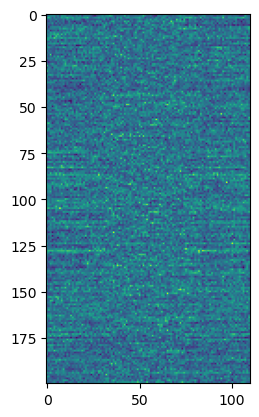

In [10]:
#region_name='V4'
region_name='IT'
animal_name='Tito'
#animal_name='Chabo'

#struc=np.load('dicarlo_data2.npz')
s=np.load(region_name+'_'+animal_name+'.npz',allow_pickle=True)

Xs=s['Xs']
objs=s['objs']

#X=struc['V4data']
#X=struc['ITdata']

#M=V4data

#Xs=Xs-np.mean(Xs,axis=1)[:,None,:]

#Xs=Xs-np.mean(Xs,axis=2)[:,:,None]

#print(np.shape(XT0))
#sresp=[X,X]

print(np.shape(Xs))
plt.imshow(Xs[0,:200,:])

In [8]:
58+70

128

In [7]:
from jax import random


key = random.PRNGKey(0)


#region_name='V4'
region_names=['V4','IT']
animal_names=['Tito','Chabo']
#animal_name='Tito'
#animal_name='Chabo'

A_a_r_s_i=[]
for animal_name in animal_names:
    A_r_s_i=[]
    for region_name in region_names:
        #struc=np.load('dicarlo_data2.npz')
        s=np.load(region_name+'_'+animal_name+'.npz',allow_pickle=True)
        
        Xs=s['Xs']
        objs=s['objs']
        
        M=np.shape(Xs)[1]
        F=np.shape(Xs)[2]
        
        Qs=np.power(10,np.linspace(np.log10(10),np.log10(F),10)).astype(int)
        #Qs=np.power(10,np.linspace(np.log10(10),np.log10(400),10)).astype(int)
        P=M#F#2000
        
        numit=1000
        Ass=[]
        for Q in Qs:
            As=[]
            print(Q)
            for i in range(numit):
                trials_idcs=np.random.choice(np.shape(Xs)[0], size=2, replace=False)
                id0=trials_idcs[0]
                id1=trials_idcs[1]
                
                #if Q==F and i>1:
                #    As.append(results)
                
                key_A, key = random.split(key)
                random_indicesP = random.choice(key_A,M,shape=(P,),replace=False)# * sigma
                key_A, key = random.split(key)
                random_indicesQ = random.choice(key_A,F,shape=(Q,),replace=False)# * sigma
                
                Theta1=Xs[id0][random_indicesP,:][:,random_indicesQ]
                Theta2=Xs[id1][random_indicesP,:][:,random_indicesQ] 
                results=[getest_all(Theta1,Theta2,P,Q)]
                As.append(results)
            Ass.append(As)
        #Ass=np.squeeze(np.array(Ass))
        A_r_s_i.append(Ass)
    A_a_r_s_i.append(A_r_s_i)
A_a_r_s_i=np.squeeze(np.array(A_a_r_s_i))


10
10
11
12
12
13
14
15
16
17
10
13
17
22
29
37
49
64
84
109
10
12
15
19
23
29
36
45
56
70
10
12
14
17
21
26
32
39
47
58


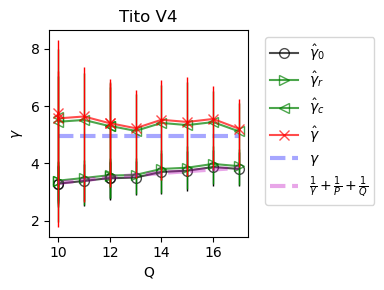

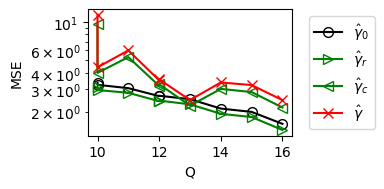

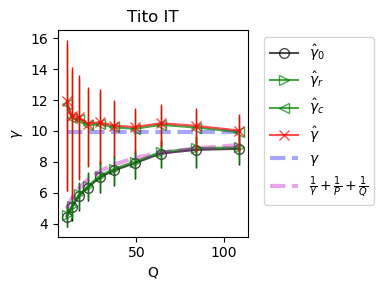

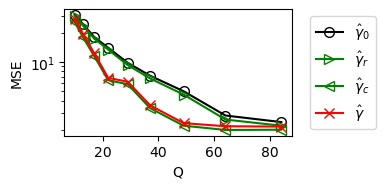

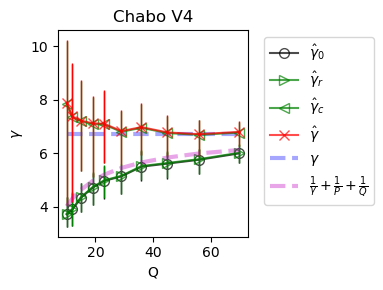

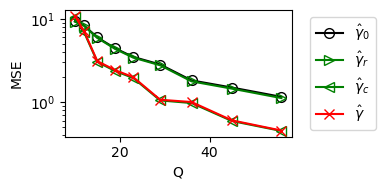

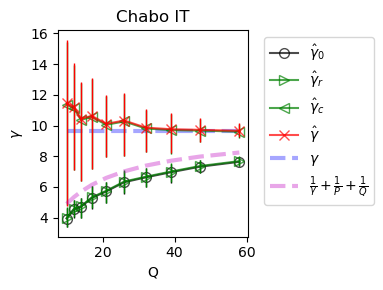

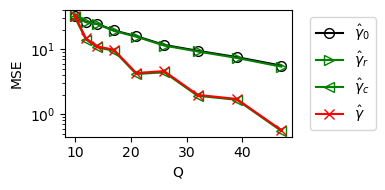

In [18]:

for ii,animal_name in enumerate(animal_names):
    for jj,region_name in enumerate(region_names):
        s=np.load(region_name+'_'+animal_name+'.npz',allow_pickle=True)
        
        Xs=s['Xs']
        objs=s['objs']
        
        M=np.shape(Xs)[1]
        F=np.shape(Xs)[2]
        
        Qs=np.power(10,np.linspace(np.log10(10),np.log10(F),10)).astype(int)

            
        fig,ax=plt.subplots(1,1,figsize=(4,3))
        fig2,ax2=plt.subplots(1,1,figsize=(4,2))

        Ass=A_a_r_s_i[ii][jj]
        
        numer,denom=np.mean(Ass[-1,:,-1,0],axis=0), np.mean(Ass[-1,:,-1,1],axis=0)
        gamma=numer/denom
        
        ms=7
        
        alpha=0.7
    
        xoi=Qs
    
        ls='-'
        lw=1.5
        
        colorvs=['k','g','g','r']
        markers=['o','>','<','x']
        labels=[r'$\hat{\gamma}_0$', r'$\hat{\gamma}_r$', r'$\hat{\gamma}_c$',r'$\hat{\gamma}$',r'$\hat{\gamma}$']
        for i,(colorv,marker,label) in enumerate(zip(colorvs,markers,labels)):
            numer, denom = Ass[:,:,i,0], Ass[:,:,i,1]
        
            qoi=numer/denom #(num_so_Q_it/np.sqrt(de2_so_a_Q_it*de2_so_b_Q_it))[:,:,i,1]
            
            
            yval=np.nanmedian(qoi,axis=1)
            lower_error=np.nanquantile(qoi,axis=1,q=0.25)
            upper_error=np.nanquantile(qoi,axis=1,q=0.75)
            asymmetric_error = [yval-lower_error, upper_error-yval]
            #yval=np.mean(qoi,axis=1)
            asymmetric_error = [np.std(qoi,axis=1),np.std(qoi,axis=1)]
            ax.errorbar(xoi, yval, yerr=asymmetric_error,c=colorv,marker='',ls='',alpha=1,lw=1,zorder=0)#, fmt='o')
            yval=np.nanmean(qoi,axis=1)
            ax.plot(xoi, yval,c=colorv,marker=marker,ls=ls,alpha=alpha,ms=ms,lw=lw,zorder=0,fillstyle='none',label=label)#, fmt='o')
        
        #ax.plot(xoi, np.mean(numer,axis=-1)/np.mean(denom,axis=-1),c=colorv)
            ax2.plot(xoi[:-1],np.mean(np.square(gamma-qoi),axis=1)[:-1], c=colorv,ms=ms,marker=marker,ls=ls,fillstyle='none',label=label)
        
        
        ax.plot(xoi,xoi*0+gamma,c='b',ls='--',label=r'$\gamma$',zorder=-10,alpha=0.35,lw=3)
        ax.plot(xoi,1/(1/xoi+1/P+1/gamma),c='m',ls='--',alpha=0.35,lw=3,label=r'$\frac{1}{\gamma} + \frac{1}{P} + \frac{1}{Q}$')
        
        ax.set_xlabel('Q')
        #ax.set_xscale('log')
        ax2.set_xlabel('Q')
        #ax2.set_xscale('log')
        ax2.set_yscale('log')
        
        #ax.set_xlim([np.min(Qs)*0.85, np.max(Qs)*1.15])
        #ax2.set_xlim([np.min(Qs)*0.85, np.max(Qs)*1.15])
        
        ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
        ax2.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
        ax.set_title(animal_name+' '+ region_name)
        
        ax2.set_ylabel('MSE')
        ax.set_ylabel(r'$\gamma$')
        fig.tight_layout()
        fig2.tight_layout()
        
        
        fig.savefig("majaj_dim_Qs_"+animal_name+"_"+region_name+".pdf", bbox_inches='tight')
        fig2.savefig("majaj_dim_mse_Qs_"+animal_name+"_"+region_name+".pdf", bbox_inches='tight')
        


In [25]:
from jax import random

key = random.PRNGKey(0)

#region_name='V4'
region_names=['V4','IT']
animal_names=['Tito','Chabo']
#animal_name='Tito'
#animal_name='Chabo'

A_a_r_s_i=[]
for animal_name in animal_names:
    A_r_s_i=[]
    for region_name in region_names:
        #struc=np.load('dicarlo_data2.npz')
        s=np.load(region_name+'_'+animal_name+'.npz',allow_pickle=True)
        
        Xs=s['Xs']
        objs=s['objs']
        
        M=np.shape(Xs)[1]
        F=np.shape(Xs)[2]
        
        Ps=np.power(10,np.linspace(np.log10(200),np.log10(M),10)).astype(int)
        #Qs=np.power(10,np.linspace(np.log10(10),np.log10(400),10)).astype(int)
        Q=F#F#2000
        
        numit=1000
        Ass=[]
        for P in Ps:
            As=[]
            print(P)
            for i in range(numit):
                trials_idcs=np.random.choice(np.shape(Xs)[0], size=2, replace=False)
                id0=trials_idcs[0]
                id1=trials_idcs[1]
                
                #if Q==F and i>1:
                #    As.append(results)
                
                key_A, key = random.split(key)
                random_indicesP = random.choice(key_A,M,shape=(P,),replace=False)# * sigma
                key_A, key = random.split(key)
                random_indicesQ = random.choice(key_A,F,shape=(Q,),replace=False)# * sigma
                
                Theta1=Xs[id0][random_indicesP,:][:,random_indicesQ]
                Theta2=Xs[id1][random_indicesP,:][:,random_indicesQ] 
                results=[getest_all(Theta1,Theta2,P,Q)]
                As.append(results)
            Ass.append(As)
        #Ass=np.squeeze(np.array(Ass))
        A_r_s_i.append(Ass)
    A_a_r_s_i.append(A_r_s_i)
A_a_r_s_i=np.squeeze(np.array(A_a_r_s_i))


200
265
352
467
621
824
1094
1453
1929
2562
200
265
352
467
621
824
1094
1453
1929
2562
200
265
352
467
621
824
1094
1453
1929
2562
200
265
352
467
621
824
1094
1453
1929
2562


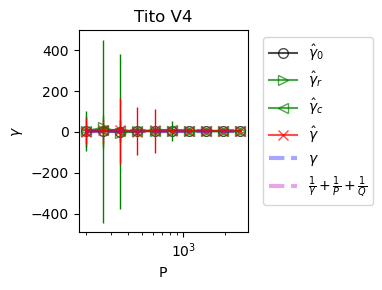

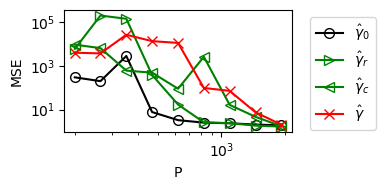

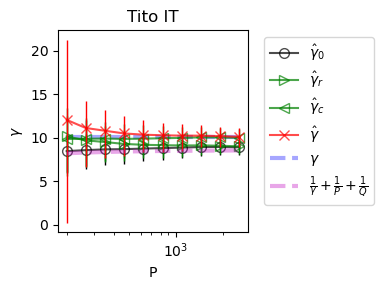

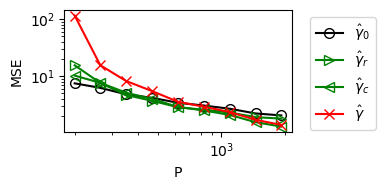

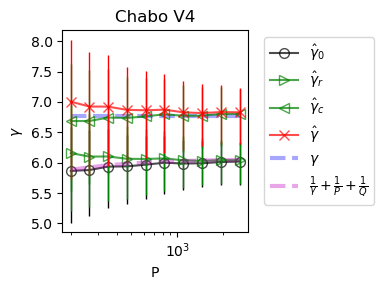

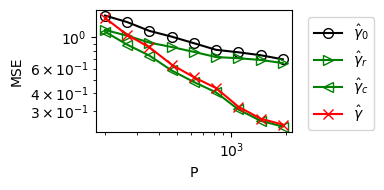

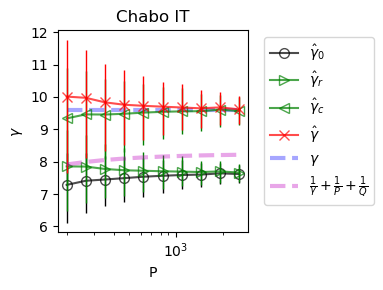

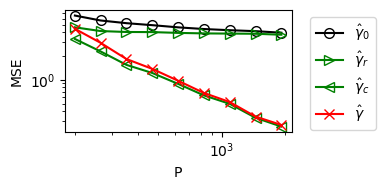

In [26]:

for ii,animal_name in enumerate(animal_names):
    for jj,region_name in enumerate(region_names):
        s=np.load(region_name+'_'+animal_name+'.npz',allow_pickle=True)
        
        Xs=s['Xs']
        objs=s['objs']
        
        M=np.shape(Xs)[1]
        F=np.shape(Xs)[2]
        
        Ps=np.power(10,np.linspace(np.log10(200),np.log10(M),10)).astype(int)

            
        fig,ax=plt.subplots(1,1,figsize=(4,3))
        fig2,ax2=plt.subplots(1,1,figsize=(4,2))

        Ass=A_a_r_s_i[ii][jj]
        
        numer,denom=np.mean(Ass[-1,:,-1,0],axis=0), np.mean(Ass[-1,:,-1,1],axis=0)
        gamma=numer/denom
        
        ms=7
        
        alpha=0.7
    
        xoi=Ps
    
        ls='-'
        lw=1.5
        
        colorvs=['k','g','g','r']
        markers=['o','>','<','x']
        labels=[r'$\hat{\gamma}_0$', r'$\hat{\gamma}_r$', r'$\hat{\gamma}_c$',r'$\hat{\gamma}$',r'$\hat{\gamma}$']
        for i,(colorv,marker,label) in enumerate(zip(colorvs,markers,labels)):
            numer, denom = Ass[:,:,i,0], Ass[:,:,i,1]
        
            qoi=numer/denom #(num_so_Q_it/np.sqrt(de2_so_a_Q_it*de2_so_b_Q_it))[:,:,i,1]
            
            
            yval=np.nanmedian(qoi,axis=1)
            lower_error=np.nanquantile(qoi,axis=1,q=0.25)
            upper_error=np.nanquantile(qoi,axis=1,q=0.75)
            asymmetric_error = [yval-lower_error, upper_error-yval]
            #yval=np.mean(qoi,axis=1)
            asymmetric_error = [np.std(qoi,axis=1),np.std(qoi,axis=1)]
            ax.errorbar(xoi, yval, yerr=asymmetric_error,c=colorv,marker='',ls='',alpha=1,lw=1,zorder=0)#, fmt='o')
            yval=np.nanmean(qoi,axis=1)
            ax.plot(xoi, yval,c=colorv,marker=marker,ls=ls,alpha=alpha,ms=ms,lw=lw,zorder=0,fillstyle='none',label=label)#, fmt='o')
        
        #ax.plot(xoi, np.mean(numer,axis=-1)/np.mean(denom,axis=-1),c=colorv)
            ax2.plot(xoi[:-1],np.mean(np.square(gamma-qoi),axis=1)[:-1], c=colorv,ms=ms,marker=marker,ls=ls,fillstyle='none',label=label)
        
        
        ax.plot(xoi,xoi*0+gamma,c='b',ls='--',label=r'$\gamma$',zorder=-10,alpha=0.35,lw=3)
        ax.plot(xoi,1/(1/xoi+1/Q+1/gamma),c='m',ls='--',alpha=0.35,lw=3,label=r'$\frac{1}{\gamma} + \frac{1}{P} + \frac{1}{Q}$')
        
        ax.set_xlabel('P')
        ax.set_xscale('log')
        ax2.set_xlabel('P')
        ax2.set_xscale('log')
        ax2.set_yscale('log')
        
        #ax.set_xlim([np.min(Qs)*0.85, np.max(Qs)*1.15])
        #ax2.set_xlim([np.min(Qs)*0.85, np.max(Qs)*1.15])
        
        ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
        ax2.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
        ax.set_title(animal_name+' '+ region_name)
        
        ax2.set_ylabel('MSE')
        ax.set_ylabel(r'$\gamma$')
        fig.tight_layout()
        fig2.tight_layout()
        
        
        fig.savefig("majaj_dim_Ps_"+animal_name+"_"+region_name+".pdf", bbox_inches='tight')
        fig2.savefig("majaj_dim_mse_Ps_"+animal_name+"_"+region_name+".pdf", bbox_inches='tight')
        


<>:94: SyntaxWarning: invalid escape sequence '\g'
<>:94: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_437788/139411521.py:94: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title('Q={}, $\gamma$={:.2f}'.format(Q,yval[-1]),fontsize=11)


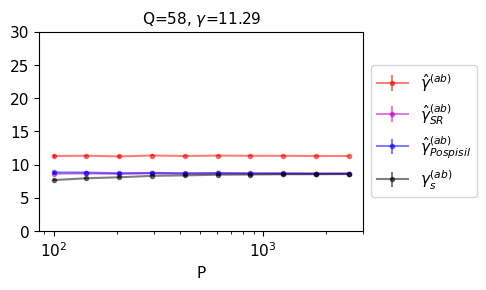

In [96]:

plt.rcParams.update({'font.size': 11})

BiasCorrect=False

fig,ax=plt.subplots(1,1,figsize=(5,3))
#ax.plot(Ps,gims,c='k',label='theory')

xoi=Ps
qoi=GTR

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='r',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}$')#, fmt='o')


xoi=Ps
qoi=GTR2

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='m',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}_{SR}$')#, fmt='o')

xoi=Ps
qoi=GTR3

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='b',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}_{Pospisil}$')#, fmt='o')


xoi=Ps
qoi=GOS

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
#ax.errorbar(xoi, yval, yerr=asymmetric_error,c='r',marker='o',ls='--',alpha=0.5,ms=3,zorder=100)#, fmt='o')

xoi=Ps
qoi=GOS2

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
#ax.errorbar(xoi, yval, yerr=asymmetric_error,c='m',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=Ps
qoi=GOS3

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
#ax.errorbar(xoi, yval, yerr=asymmetric_error,c='b',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=Ps
qoi=GOS4

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
#ax.errorbar(xoi, yval, yerr=asymmetric_error,c='g',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}_{Dahmen}$')#, fmt='o')




xoi=Ps
qoi=GS
yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='k',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\gamma_s^{(ab)}$')#, fmt='o')

#ax.hlines(GT,np.min(xoi),np.max(xoi),color='c',label=r'$\gamma$',lw=2,alpha=0.5)

ax.set_xlabel('P')
ax.legend(fontsize=11)


qoi=GTR
yval=np.array([np.mean(qoiv) for qoiv in qoi])


ax.set_title('Q={}, $\gamma$={:.2f}'.format(Q,yval[-1]),fontsize=11)
ax.set_ylim([0,30])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


plt.tight_layout()

#fig.savefig('St_vary_P_fix_Q_{}_comp.pdf'.format(Q),format='pdf', bbox_inches = "tight")
            
ax.set_xscale('log')

#fig.savefig('St_vary_P_fix_Q_{}_comp_log.pdf'.format(Q),format='pdf', bbox_inches = "tight")


# By class

In [149]:
region_name='V4'
#region_name='IT'
#animal_name='Tito'
animal_name='Chabo'

#struc=np.load('dicarlo_data2.npz')
s=np.load(region_name+'_'+animal_name+'.npz',allow_pickle=True)

Xs_all=s['Xs']
objs=s['objs']

unobj=np.unique(objs[0])
Xos=[]
for objn in unobj:
    obj_idx=objs[0]==objn
    Xos.append(Xs_all[:,obj_idx,:])
    


#X=struc['V4data']
#X=struc['ITdata']

#M=V4data

#print(np.shape(XT0))
#sresp=[X,X]

#print(np.shape(Xs))
#plt.imshow(Xs[0,:200,:])


In [150]:
from jax import random

GTR=[]
GTR2=[]
GTR3=[]
GT=[]
GS=[]
GOS=[]
GOS2=[]
GOS3=[]
GOS4=[]
for ic, Xs in enumerate(Xos):
    key = random.PRNGKey(0)

    Xs=Xs-np.mean(Xs,axis=1)[:,None,:]
    Xs=Xs-np.mean(Xs,axis=2)[:,:,None]

    M=np.shape(Xs)[1]
    F=np.shape(Xs)[2]

    P=M
    Q=F

    key_A, key = random.split(key)
    random_indicesQ = random.choice(key_A,F,shape=(Q,),replace=False)# * sigma

    numit=3
    N=300

    
    gts=[]
    gvs=[]
    grs=[]
    grs2=[]
    grs3=[]

    nums=[]
    dens=[]
    nums2=[]
    dens2=[]
    nums3=[]
    dens3=[]
    nums4=[]
    dens4=[]
    for k in range(numit):


        numers=[]
        denoms=[]
        numers2=[]
        denoms2=[]
        numers3=[]
        denoms3=[]
        numers4=[]
        denoms4=[]
        gss=[]
        for j in range(N):
            print('\r{:.2f}, {:.2f}'.format((ic+1)/len(Xos) ,(j+1)/N),end='')

            trials_idcs=np.random.choice(np.shape(Xs)[0], size=2, replace=False)
            id0=trials_idcs[0]
            id1=trials_idcs[1]

            key_A, key = random.split(key)
            random_indicesP = random.choice(key_A,M,shape=(P,),replace=False)# * sigma
            Theta1=Xs[id0][random_indicesP,:][:,random_indicesQ]
            Theta2=Xs[id1][random_indicesP,:][:,random_indicesQ] 

            numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=jnp.inf)
            #numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=jnp.shape(Theta1)[1])

            numers.append(numer)
            denoms.append(denom)
            gss.append(gammas)

            numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=Q)
            numers2.append(numer)
            denoms2.append(denom)            

            numer , denom = getKsTerms2(Theta1,Theta2)            
            numers3.append(numer)
            denoms3.append(denom)

            numer, denom = cal_gauss_est(Theta1,Theta1)
            numers4.append(numer)
            denoms4.append(denom)

        numers=np.array(numers)
        denoms=np.array(denoms)
        gamp=np.mean(numers)/np.mean(denoms)
        bias=getBias(numers,denoms)


        gamp2=np.mean(numers2)/np.mean(denoms2)
        gamp3=np.mean(numers3)/np.mean(denoms3)

        grs.append(gamp)
        gts.append(gamp-bias)
        gvs.append(np.mean(gss))
        nums.append(numers)
        dens.append(denoms)


        grs2.append(gamp2)
        grs3.append(gamp3)

        nums2.append(numers2)
        dens2.append(denoms2)
        nums3.append(numers3)
        dens3.append(denoms3)
        nums4.append(numers4)
        dens4.append(denoms4)

    GTR.append(np.array(grs))
    GTR2.append(np.array(grs2))
    GTR3.append(np.array(grs3))

    GT.append(np.array(gts))
    GS.append(np.array(gvs))
    GOS.append(np.concatenate(nums)/np.concatenate(dens))
    GOS2.append(np.concatenate(nums2)/np.concatenate(dens2))
    GOS3.append(np.concatenate(nums3)/np.concatenate(dens3))
    GOS4.append(np.concatenate(nums4)/np.concatenate(dens4))



1.00, 1.00

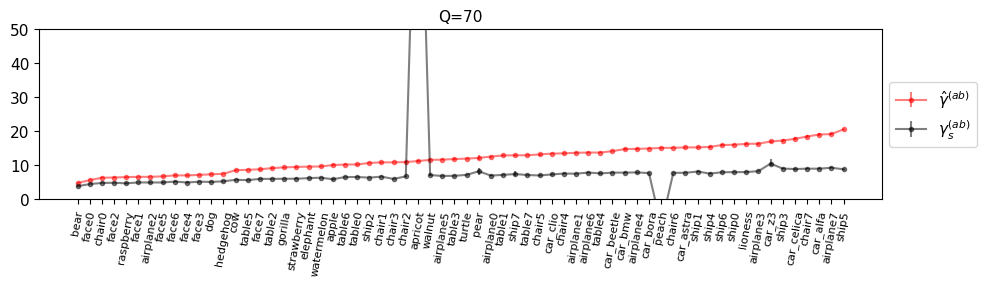

In [151]:
GTR=np.array(GTR)
GTR2=np.array(GTR2)
GTR3=np.array(GTR3)
GS=np.array(GS)

plt.rcParams.update({'font.size': 11})

BiasCorrect=False

fig,ax=plt.subplots(1,1,figsize=(10,3))
#ax.plot(Ps,gims,c='k',label='theory')

xoi=np.arange(len(Xos))

sortI=np.argsort(np.mean(GTR,axis=1))

qoi=GTR[sortI,:]

yval=np.mean(qoi,axis=1)
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='r',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}$')#, fmt='o')


qoi=GTR2[sortI,:]

yval=np.mean(qoi,axis=1)
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
#ax.errorbar(xoi, yval, yerr=asymmetric_error,c='m',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}_{SR}$')#, fmt='o')

qoi=GTR3[sortI,:]

yval=np.mean(qoi,axis=1)
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
#ax.errorbar(xoi, yval, yerr=asymmetric_error,c='b',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}_{Pospisil}$')#, fmt='o')



qoi=GS[sortI,:]
yval=np.mean(qoi,axis=1)
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='k',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\gamma_s^{(ab)}$')#, fmt='o')

#ax.hlines(GT,np.min(xoi),np.max(xoi),color='c',label=r'$\gamma$',lw=2,alpha=0.5)

#ax.set_xlabel('P')
ax.legend(fontsize=11)


ax.set_title('Q={}'.format(Q),fontsize=11)
ax.set_ylim([0,50])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.xticks(xoi)

ax.set_xticklabels(unobj[sortI], rotation = 80,fontsize=8)

plt.tight_layout()

#fig.savefig('St_vary_P_fix_Q_{}_comp.pdf'.format(Q),format='pdf', bbox_inches = "tight")
            
#ax.set_xscale('log')

#fig.savefig('St_vary_P_fix_Q_{}_comp_log.pdf'.format(Q),format='pdf', bbox_inches = "tight")



In [131]:
unobj[sortI]

array(['face1', 'face6', 'bear', 'table2', 'face2', 'car_astra', 'face4',
       'face0', 'face5', 'face3', 'dog', 'airplane1', 'ship3', 'face7',
       'turtle', 'elephant', 'chair6', 'airplane5', 'cow', 'table6',
       'watermelon', 'chair0', 'hedgehog', 'walnut', 'strawberry',
       'airplane3', 'table7', 'airplane4', 'raspberry', 'car_bora',
       'airplane2', 'car_beetle', 'table4', 'table3', 'table5', 'ship4',
       'chair2', 'pear', 'lioness', 'apricot', 'table0', 'gorilla',
       'chair3', 'car_celica', 'chair4', 'chair5', 'car_clio',
       'airplane6', 'ship2', 'car_z3', 'ship0', 'airplane0', 'chair1',
       'car_alfa', 'table1', 'ship7', 'airplane7', 'ship6', 'apple',
       'car_bmw', 'ship1', 'ship5', 'peach', 'chair7'], dtype=object)

In [ ]:
from jax import random


key = random.PRNGKey(1000)

M=np.shape(sresp[0])[0]
F=np.shape(sresp[0])[1]

Ps=np.power(10,np.linspace(np.log10(30),np.log10(M),10)).astype(int)
#Qs=np.power(10,np.linspace(np.log10(10),np.log10(400),10)).astype(int)
Q=1000

numit=30
N=10
GTR=[]
GTR2=[]
GTR3=[]
GT=[]
GS=[]
GOS=[]
GOS2=[]
GOS3=[]
GOS4=[]
for i,P in enumerate(Ps):
    print('\r{:.2f}'.format(i/np.shape(Ps)[0]),end='')
        
    gts=[]
    gvs=[]
    grs=[]
    grs2=[]
    grs3=[]

    nums=[]
    dens=[]
    nums2=[]
    dens2=[]
    nums3=[]
    dens3=[]
    nums4=[]
    dens4=[]
    for k in range(numit):
        numers=[]
        denoms=[]
        numers2=[]
        denoms2=[]
        numers3=[]
        denoms3=[]
        numers4=[]
        denoms4=[]
        gss=[]
        for j in range(N):

            key_A, key = random.split(key)
            random_indicesP = random.choice(key_A,M,shape=(P,),replace=False)# * sigma
            key_A, key = random.split(key)
            random_indicesQ = random.choice(key_A,F,shape=(Q,),replace=False)
            
            Theta1=sresp[0][random_indicesP,:][:,random_indicesQ]
            Theta2=sresp[1][random_indicesP,:][:,random_indicesQ] 

            numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=jnp.inf)
            #numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=jnp.shape(Theta1)[1])
            
            numers.append(numer)
            denoms.append(denom)
            gss.append(gammas)
            
            numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=Q)
            numers2.append(numer)
            denoms2.append(denom)            
            
            numer , denom = getKsTerms2(Theta1,Theta2)            
            numers3.append(numer)
            denoms3.append(denom)

            numer, denom = cal_gauss_est(Theta1,Theta1)
            numers4.append(numer)
            denoms4.append(denom)
            
        numers=np.array(numers)
        denoms=np.array(denoms)
        gamp=np.mean(numers)/np.mean(denoms)
        bias=getBias(numers,denoms)
        grs.append(gamp)
        gts.append(gamp-bias)
        gvs.append(np.mean(gss))
        nums.append(numers)
        dens.append(denoms)
        
        gamp2=np.mean(numers2)/np.mean(denoms2)
        gamp3=np.mean(numers3)/np.mean(denoms3)
        
        grs2.append(gamp2)
        grs3.append(gamp3)
        
        nums2.append(numers2)
        dens2.append(denoms2)
        nums3.append(numers3)
        dens3.append(denoms3)
        nums4.append(numers4)
        dens4.append(denoms4)
        
    GTR.append(np.array(grs))
    GTR2.append(np.array(grs2))
    GTR3.append(np.array(grs3))

    GT.append(np.array(gts))
    GS.append(np.array(gvs))
    GOS.append(np.concatenate(nums)/np.concatenate(dens))
    GOS2.append(np.concatenate(nums2)/np.concatenate(dens2))
    GOS3.append(np.concatenate(nums3)/np.concatenate(dens3))
    GOS4.append(np.concatenate(nums4)/np.concatenate(dens4))



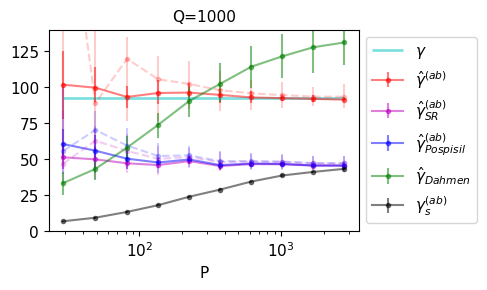

In [83]:

plt.rcParams.update({'font.size': 11})

BiasCorrect=False

fig,ax=plt.subplots(1,1,figsize=(5,3))
#ax.plot(Ps,gims,c='k',label='theory')

xoi=Ps
qoi=GTR

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='r',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}$')#, fmt='o')


xoi=Ps
qoi=GTR2

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='m',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}_{SR}$')#, fmt='o')

xoi=Ps
qoi=GTR3

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='b',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}_{Pospisil}$')#, fmt='o')


xoi=Ps
qoi=GOS

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='r',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=Ps
qoi=GOS2

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='m',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=Ps
qoi=GOS3

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='b',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=Ps
qoi=GOS4

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='g',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}_{Dahmen}$')#, fmt='o')




xoi=Ps
qoi=GS
yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='k',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\gamma_s^{(ab)}$')#, fmt='o')

ax.hlines(GTv,np.min(xoi),np.max(xoi),color='c',label=r'$\gamma$',lw=2,alpha=0.5)

ax.set_xlabel('P')
ax.legend(fontsize=11)

ax.set_title('Q={}'.format(Q),fontsize=11)
ax.set_ylim([0,140])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


plt.tight_layout()

fig.savefig('St_vary_P_shuffle_Q_{}_comp.pdf'.format(Q),format='pdf', bbox_inches = "tight")
            
ax.set_xscale('log')

fig.savefig('St_vary_P_shuffle_Q_{}_comp_log.pdf'.format(Q),format='pdf', bbox_inches = "tight")


# Power law fitting

In [58]:
def getSecond(Xs1,Xs2,M=jnp.inf,F=jnp.inf):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    
    Phr=(P-1)/(M-1)
    Qhr=(Q-1)/(F-1)
    Pr=P/M
    Qr=Q/F
    
    #if False:
    if P<Q:
        Kv=1/Q*jnp.matmul(Xs1,Xs2.T)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))
        #nTrKs_min2=jnp.mean(jnp.square(1/Q*jnp.matmul(Xs1,Xs2.T)))
    else:
        Kv=1/P*jnp.matmul(Xs1.T,Xs2)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))
        #nTrKs_min2=jnp.mean(jnp.square(1/P*jnp.matmul(Xs1.T,Xs2)))
            
    Term2=-(1-Phr)/P * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=1)))
    Term3=-(1-Qhr)/Q * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=0)))
    Term4=((1-Phr)*(1-Qhr))/(P*Q) * jnp.mean(jnp.power(Xs1*Xs2,2))
        
    v =  Term2 + Term3 + Term4
    
    #nsTrKs = jnp.square(jnp.mean(Xs1*Xs2))
    
    # if M and F are infinite, or even if M and F are finite:
    denom =  (nTrKs_min2 +v)
    #numer =  (nsTrKs +v)
    # There are some scaling differences, but all that matters is numer/denom, which cancels out the scaling factors.
    
    denom=denom*P/(P-1)
    return denom


def getSecond_K(Xs1,Xs2):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    Kc = jnp.matmul(Xs1,Xs2.T)/Q
    return 2*jnp.trace(jnp.matmul(jnp.triu(Kc, 1),Kc))/(P*(P-1))
        

def compute_A(P, Q, Phi):
    return jnp.mean(Phi**6)
def compute_B(P, Q, Phi):
    return jnp.mean(jnp.mean(Phi**2, axis=1) * jnp.mean(Phi**4, axis=1))
def compute_C(P, Q, Phi):
    return jnp.mean(jnp.mean(Phi**2, axis=1)**3)
def compute_D(P, Q, Phi):
    one=jnp.mean(Phi**2,axis=1)
    sec=(jnp.matmul(Phi,Phi.T)/Q)**2
    return jnp.mean(one[:,None]*sec)
def compute_bar_B(P, Q, Phi):
    return jnp.mean(np.mean(Phi**2, axis=0) * jnp.mean(Phi**4, axis=0))
def compute_bar_C(P, Q, Phi):
    return jnp.mean(jnp.mean(Phi**2, axis=0)**3)
def compute_bar_D(P, Q, Phi):
    one=jnp.mean(Phi**2,axis=0)
    sec=(jnp.matmul(Phi.T,Phi)/P)**2
    return jnp.mean(one[:,None]*sec)
def compute_E(P, Q, Phi):
    return jnp.mean(jnp.matmul(Phi**3,Phi.T)/Q * jnp.matmul(Phi,Phi.T)/Q)
def compute_F(P, Q, Phi):
    return  jnp.mean(jnp.mean(Phi**2,axis=1)[:,None] * jnp.matmul(Phi**2,Phi.T**2)/Q)
def compute_G_prime(P, Q, K_Q):
    return jnp.trace(jnp.linalg.matrix_power(K_Q/P,3))
def getThird(Phi):
    P=np.shape(Phi)[0]
    Q=np.shape(Phi)[1]
    A = compute_A(P, Q, Phi)
    B = compute_B(P, Q, Phi)
    C = compute_C(P, Q, Phi)
    D = compute_D(P, Q, Phi)
    bar_B = compute_bar_B(P, Q, Phi)
    bar_C = compute_bar_C(P, Q, Phi)
    bar_D = compute_bar_D(P, Q, Phi)
    E = compute_E(P, Q, Phi)
    F = compute_F(P, Q, Phi)
    K_Q = jnp.matmul(Phi, Phi.T)/Q
    G_prime = compute_G_prime(P, Q, K_Q)
    
    return G_prime, D, bar_D, C, bar_C, B, bar_B, E, F, A


def getThird_K(Xs1,Xs2):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    Kc = jnp.matmul(Xs1,Xs2.T)/Q
    return 6*jnp.trace(jnp.matmul(jnp.linalg.matrix_power(jnp.triu(Kc, 1),2),Kc))/P/(P-1)/(P-2)


    
Theta1=sresp[0]#[:P,:][:,:Q]
Theta2=sresp[1]#[:P,:][:,:Q]


second=getSecond(Theta1,Theta2)
second_k=getSecond_K(Theta1,Theta2)
#third=getThird(Theta1)

P=np.shape(Theta1)[0]
Q=np.shape(Theta1)[1]

    

third_k=getThird_K(Theta1,Theta2)

print(second)
print(second_k)
print(third)
print(third_k)


0.0050244024
0.00560546
0.00208032
0.0001103726


In [61]:
key = random.PRNGKey(1000)

numit=20
ths=[]
for i in range(numit):
    print(i)
    key_A, key = random.split(key)

    pc=int(P/2)
    random_indicesP = random.choice(key_A,P,shape=(pc,),replace=False)# * sigma
    ThetaM=np.copy(Theta1)
    ThetaM[random_indicesP,:]=Theta2[random_indicesP,:]

    G_prime, D, bar_D, C, bar_C, B, bar_B, E, F, A = getThird(ThetaM)
    G = (P/(P-1)*P/(P-2)* Q/(Q-1)*Q/(Q-2) * G_prime)+(
        - 3* P * Q * (Q * D + P * bar_D)
            + 2 * (Q**2 * C + P**2 * bar_C)
            - 6 * (Q * B + P * bar_B)
            + 6 * P * Q * E
            + 3 * P * Q * F
            + 4 * A )/(P-1)/(P-2)/(Q-1)/(Q-2)
    ths.append(G)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [67]:
third=np.mean(ths)
print(third)

first=np.mean(Theta1*Theta2)
print(first)

0.0022180001
0.683509290314664


In [111]:
from scipy.special import zeta

def Hsum(alpha,H):
    n=np.arange(H)+1
    return np.sum(1/np.power(n,alpha))

def bplM(alpha,beta,H,scale):
    
    r=np.power(H,alpha-beta)
    fm = Hsum(beta,H) + r*(zeta(alpha)-Hsum(alpha,H)) 

    rp=np.square(r)
    sm = Hsum(2*beta,H) + rp*(zeta(2*alpha)-Hsum(2*alpha,H))
    
    rt=r**3
    tm = Hsum(3*beta,H) + rt*(zeta(3*alpha)-Hsum(3*alpha,H))
    
    return fm*scale, sm*scale**2, tm*scale**3

scale=1
alphas=np.linspace(1.01,4,10)
betas=np.linspace(0.5,4,11)
Hs=np.linspace(3,20,12).astype(int)

A=np.zeros((np.shape(alphas)[0],np.shape(betas)[0],np.shape(Hs)[0]))
for i,alpha in enumerate(alphas):
    for j,beta in enumerate(betas):
        for k,H in enumerate(Hs):
            fm,sm,tm=bplM(alpha,beta,H,scale)
            A[i,j,k] = (fm-first)**2 + (sm-second)**2 + (tm-third)**2
        

In [117]:
tm

1.000246086553308

Text(0, 0.5, 'alphas')

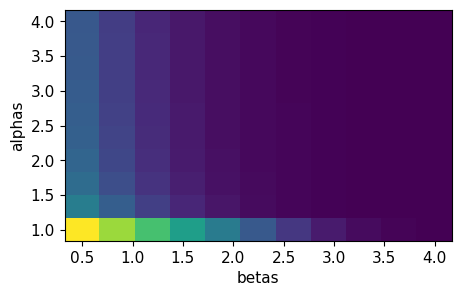

In [112]:
fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.pcolor(betas,alphas,np.log10(A[:,:,5]))
ax.set_xlabel('betas')
ax.set_ylabel('alphas')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import zeta

def Hsum(alpha,H):
    n=np.arange(H)+1
    return np.sum(1/np.power(n,alpha))

def getBPdim(alpha,beta,H):
    r=np.power(H,alpha-beta)
    h = ( Hsum(beta,H) + r*(zeta(alpha)-Hsum(alpha,H)) )**2

    rp=np.square(r)
    g = Hsum(2*beta,H) + rp*(zeta(2*alpha)-Hsum(2*alpha,H))
    return h/g


alpha=1.23
dimval=getBPdim(alpha,0.5,10)


print(dimval)


# Simplified codes

In [ ]:
#most general
def getKsTerms(Xs1,Xs2,M=jnp.inf,F=jnp.inf):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    
    Phr=(P-1)/(M-1)
    Qhr=(Q-1)/(F-1)

    if P<Q:
        Kv=1/Q*jnp.matmul(Xs1,Xs2.T)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))
    else:
        Kv=1/P*jnp.matmul(Xs1.T,Xs2)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))
            
    Term2=-(1-Phr)/P * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=1)))
    Term3=-(1-Qhr)/Q * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=0)))
    Term4=((1-Phr)*(1-Qhr))/(P*Q) * jnp.mean(jnp.power(Xs1*Xs2,2))
        
    v =  Term2 + Term3 + Term4
    
    nsTrKs = jnp.square(jnp.mean(Xs1*Xs2))
    
    denom =  (nTrKs_min2 +v)
    numer =  (nsTrKs +v)
    
    return numer , denom 


def getKsTerms(Xs):
    P=jnp.shape(Xs)[0]
    Q=jnp.shape(Xs)[1]
    
    if P<Q:
        Kv=1/Q*jnp.matmul(Xs,Xs.T)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))
    else:
        Kv=1/P*jnp.matmul(Xs.T,Xs)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))
            
    Term2=-1/P * jnp.mean(jnp.square(jnp.mean(Xs*Xs,axis=1)))
    Term3=-1/Q * jnp.mean(jnp.square(jnp.mean(Xs*Xs,axis=0)))
    Term4=1/(P*Q) * jnp.mean(jnp.power(Xs*Xs,2))
        
    v =  Term2 + Term3 + Term4
    
    nsTrKs = jnp.square(jnp.mean(Xs*Xs))
    
    denom =  nTrKs_min2 +v
    numer =  nsTrKs +v
    
    return numer , denom 




In [10]:

A_a_r_s_i=np.squeeze(np.array(A_a_r_s_i))
